# Level 2 (grokking) attention-head circuit

This replaces the logit-space Fourier-readout version. The Level 2 unit is now the
**whole attention head**, structurally identical to the IOI Level 2 analysis
(`03bis_level2_heads_IOI_.ipynb`): every head is mean-ablated at the readout position,
each head is restored alone, and faithfulness is the activation-patching recovery score.

The one-layer modular-addition model has 4 attention heads. Nanda et al. (2023, App. C)
show these heads are causally load-bearing (zero-ablating them drives loss to 24.3,
worse than chance) and that each head approximately computes a degree-2 polynomial of a
single key frequency.

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level2")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
L1_RESULTS = Path("../results/level1/level1_results.json")
MODEL_PATH = Path("../data/grokking_model.pt")

Using device: cpu


Dataset and model

identical config to Levels 1 and 3 (`use_attn_result=True` so per-head outputs are hookable at `blocks.0.attn.hook_result`).

In [12]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels_all = (aa + bb) % P
inputs_all = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs_all)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs_all[idx[n_test:]]
test_inputs  = inputs_all[idx[:n_test]]
test_labels  = labels_all[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

with torch.no_grad():
    te_acc = (model(test_inputs.to(device))[:, -1, :].argmax(-1)
              == test_labels.to(device)).float().mean()
print(f"Test accuracy: {te_acc:.4f}")

N_HEADS = model.cfg.n_heads
RESULT_HOOK = "blocks.0.attn.hook_result"   # [batch, seq, n_heads, d_model]

Moving model to device:  cpu
Test accuracy: 1.0000


Faithfulness metric and recovery score 

In [13]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item()
            - corrupted_metric.mean().item()) / gap

Evaluation set and baselines

Same 200-example evaluation slice as Level 1. The ablation baseline is the **mean head
output at the readout (`=`) position**, taken over the evaluation set: the head-level
analogue of the mean-activation ablation used at Level 1, and the same construction as the
IOI Level 2 mean ablation (there over pABC; here over the eval set, since modular addition
has no name-duplication signal to destroy).

In [14]:
N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

# Clean metric
with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

# Cache clean per-head outputs at the readout position
with torch.no_grad():
    _, eval_cache = model.run_with_cache(
        eval_x, names_filter=lambda n: n == RESULT_HOOK)
clean_head_acts = eval_cache[RESULT_HOOK][:, -1, :, :]   # [N_EVAL, n_heads, d_model]

# Ablation baseline: mean head output at readout position over the eval set
mean_head = clean_head_acts.mean(dim=0).to(device)       # [n_heads, d_model]

In [15]:
# Corrupted baseline: mean-ablate ALL heads at the readout position
def make_full_ablation_hook(mean):
    def hook_fn(value, hook):
        value[:, -1, :, :] = mean.unsqueeze(0).expand(value.shape[0], -1, -1)
        return value
    return hook_fn

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(RESULT_HOOK, make_full_ablation_hook(mean_head))]
    )[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean     logit(correct): {clean_metric.mean():.4f}")
print(f"Corrupted logit(correct): {corrupted_metric.mean():.4f}")
print(f"Gap to recover:           {(clean_metric - corrupted_metric).mean():.4f}")

Clean     logit(correct): 38.2160
Corrupted logit(correct): -6.7378
Gap to recover:           44.9538


Per-head patching loop

Ablate all heads to the mean, then restore one head to its clean value

In [16]:
def make_single_head_restore_hook(mean, clean_acts, target_head):
    def hook_fn(value, hook):
        bsz = value.shape[0]
        value[:, -1, :, :] = mean.unsqueeze(0).expand(bsz, -1, -1)
        value[:, -1, target_head, :] = clean_acts[:bsz, target_head, :].to(value.device)
        return value
    return hook_fn

head_scores = {}
for h in tqdm(range(N_HEADS), desc="Patching heads"):
    with torch.no_grad():
        logits = model.run_with_hooks(
            eval_x,
            fwd_hooks=[(RESULT_HOOK,
                        make_single_head_restore_hook(mean_head, clean_head_acts, h))]
        )[:, -1, :]
    patched_metric = logit_of_correct(logits, eval_y)
    head_scores[f"head_{h}"] = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"  head_{h}: RS={head_scores[f'head_{h}']:.4f}")

Patching heads:   0%|          | 0/4 [00:00<?, ?it/s]

  head_0: RS=0.1734
  head_1: RS=0.1259
  head_2: RS=0.1689
  head_3: RS=0.1312


Criterion 1 (faithfulness) and Criterion 2 (description length)

Greedy circuit construction: heads are sorted by individual RS (descending), then added one
at a time, measuring joint faithfulness after each addition. We stop as soon as the cumulative
RS ≥ RS_TARGET = 0.90, identical to the IOI Level 2 strategy. Description length = |circuit| / 4.

In [17]:
RS_TARGET = 0.90

# Sort heads by individual RS, keep positive-RS heads only
all_head_scores_sorted = sorted(head_scores.items(), key=lambda x: x[1], reverse=True)
pos_heads = [(name, rs) for name, rs in all_head_scores_sorted if rs > 0]

print(f"Heads with positive RS : {len(pos_heads)} / {N_HEADS}")
print(f"Max individual RS      : {all_head_scores_sorted[0][1]:.4f}  ({all_head_scores_sorted[0][0]})")

def run_faithfulness(circuit_head_names):
    keep_idx = [int(n.split("_")[1]) for n in circuit_head_names]
    def hook_fn(value, hook):
        bsz = value.shape[0]
        value[:, -1, :, :] = mean_head.unsqueeze(0).expand(bsz, -1, -1)
        for h in keep_idx:
            value[:, -1, h, :] = clean_head_acts[:bsz, h, :].to(value.device)
        return value
    with torch.no_grad():
        logits = model.run_with_hooks(eval_x, fwd_hooks=[(RESULT_HOOK, hook_fn)])[:, -1, :]
    metric = logit_of_correct(logits, eval_y)
    return recovery_score(metric, corrupted_metric, clean_metric)

# Greedy circuit construction
circuit_heads = []
faithfulness  = 0.0
rs_curve      = []

print(f"\nBuilding greedy circuit (target RS >= {RS_TARGET})...")
for name, ind_rs in pos_heads:
    circuit_heads.append(name)
    faithfulness = run_faithfulness(circuit_heads)
    rs_curve.append(faithfulness)
    print(f"  added {name}  individual RS={ind_rs:.4f}  joint RS={faithfulness:.4f}")
    if faithfulness >= RS_TARGET:
        break

n_circuit = len(circuit_heads)
description_length = n_circuit / N_HEADS

print("=" * 57)
print("  Level 2 (grokking) — attention-head circuit")
print("=" * 57)
print(f"  RS target                      : {RS_TARGET}")
print(f"  Criterion 1  Faithfulness RS   : {faithfulness:.4f}")
print(f"  Criterion 2  Description length: {description_length:.4f}  "
      f"({n_circuit} / {N_HEADS} heads)")
print(f"  Circuit heads: {circuit_heads}")
print("=" * 57)

Heads with positive RS : 4 / 4
Max individual RS      : 0.1734  (head_0)

Building greedy circuit (target RS >= 0.9)...
  added head_0  individual RS=0.1734  joint RS=0.1734
  added head_2  individual RS=0.1689  joint RS=0.5783
  added head_3  individual RS=0.1312  joint RS=0.7379
  added head_1  individual RS=0.1259  joint RS=1.0000
  Level 2 (grokking) — attention-head circuit
  RS target                      : 0.9
  Criterion 1  Faithfulness RS   : 1.0000
  Criterion 2  Description length: 1.0000  (4 / 4 heads)
  Circuit heads: ['head_0', 'head_2', 'head_3', 'head_1']


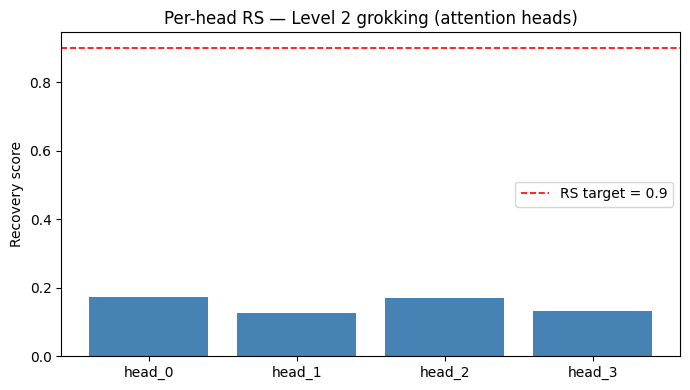

In [18]:
# Plot: per-head RS, coloured by circuit membership
names  = list(head_scores.keys())
vals   = [head_scores[n] for n in names]
colors = ["steelblue" if n in circuit_heads else "lightgray" for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, vals, color=colors)
ax.axhline(RS_TARGET, color="red", linestyle="--", linewidth=1.2, label=f"RS target = {RS_TARGET}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Recovery score")
ax.set_title("Per-head RS — Level 2 grokking (attention heads)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "level2_grokking_head_recovery.png", dpi=150)
plt.show()

Save results 

In [19]:
results = {
    "level": 2,
    "task": "modular_arithmetic_mod113",
    "method": "activation_patching_head_restoration",
    "metric": "logit_of_correct_token",
    "unit": "attention_head",
    "n_units_total": N_HEADS,
    "n_eval": N_EVAL,
    "clean_metric_mean":     clean_metric.mean().item(),
    "corrupted_metric_mean": corrupted_metric.mean().item(),
    "rs_target": RS_TARGET,
    "criterion1_faithfulness": faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_units": n_circuit,
    "criterion2_total_units": N_HEADS,
    "circuit_heads": circuit_heads,
    "all_recovery_scores": head_scores,
}

with open(RESULTS_DIR / "level2_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level2_results.json")

Saved to ..\results\level2/level2_results.json
